              precision    recall  f1-score   support

           0       0.54      0.82      0.65     69646
           1       0.56      0.25      0.34     63854

    accuracy                           0.55    133500
   macro avg       0.55      0.53      0.50    133500
weighted avg       0.55      0.55      0.50    133500

              precision    recall  f1-score   support

           0       0.52      0.81      0.64      6777
           1       0.57      0.25      0.35      6723

    accuracy                           0.53     13500
   macro avg       0.55      0.53      0.49     13500
weighted avg       0.55      0.53      0.49     13500



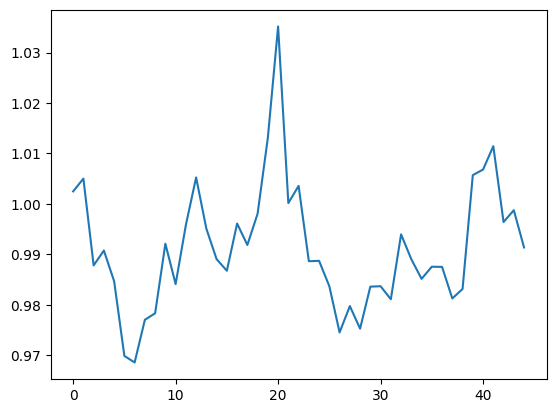

In [2]:
##############################
## Case Study (section 10.3.4)
##############################

####################################  code from chapter 5
## step 1 / full index
import numpy as np
import numpy.linalg as la
import pandas as pd
import os
import matplotlib.pyplot as plt
index_path = r'./SZ399300.TXT'

index300 = pd.read_table(index_path,\
    encoding = 'cp936',header = None)
idx = index300[:-1]
idx.columns = ['date','o','h','l','c','v','to']
idx.index = idx['date']
## step 2 / data preparation


stock_path = r'./hs300'
names = os.listdir(stock_path)
close = []
for name in names:
    spath = stock_path + '\\' + name
    df0 = pd.read_table(spath,\
        encoding = 'cp936',header = None)
    df1 = df0[:-1]
    df1.columns = ['date','o','h','l','c','v','to']
    df1.index = df1['date']
    # Use .ffill() and .bfill() instead of deprecated method= arguments
    df2 = df1.reindex(idx.index).ffill()
    df3 = df2.bfill()
    close.append(df3['c'].values)

data = np.asarray(close).T

retx = (data[1:,:]-data[:-1,:])/data[:-1,:]

#active_ret = raw - np.mean(raw,axis = 1).reshape(200,1)



# obtain traing set and test set
n = 500
n1 = 50
p = 5
train = retx[-n:-n1,:]
ret = train[p:,:].ravel()
X1 = train[4:-1,:].ravel()[:,np.newaxis]
X2 = train[3:-2,:].ravel()[:,np.newaxis]
X3 = train[2:-3,:].ravel()[:,np.newaxis]
X4 = train[1:-4,:].ravel()[:,np.newaxis]
X5 = train[:-5,:].ravel()[:,np.newaxis]
y_train = (ret>0).astype(int)
X_train = np.hstack((X5,X4,X3,X2,X1))

test = retx[-n1:,:]
ret2 = test[p:,:].ravel()
X1 = test[4:-1,:].ravel()[:,np.newaxis]
X2 = test[3:-2,:].ravel()[:,np.newaxis]
X3 = test[2:-3,:].ravel()[:,np.newaxis]
X4 = test[1:-4,:].ravel()[:,np.newaxis]
X5 = test[:-5,:].ravel()[:,np.newaxis]
y_test = (ret2>0).astype(int)
X_test = np.hstack((X5,X4,X3,X2,X1))

# model fitting
from sklearn import linear_model
from sklearn.metrics import classification_report
clf = linear_model.LogisticRegression(C=1e2,fit_intercept=True)
clf.fit(X_train,y_train)

# performance in training sample
y_pred0 = clf.predict(X_train)
print(classification_report(y_train, y_pred0))
np.corrcoef([y_train,y_pred0])
# performance in test sample
y_pred = clf.predict(X_test)
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))
np.corrcoef([y_test,y_pred]) # Information Coefficient, IC

## portfolio



holding_matrix = np.zeros((n1-p,300))
for j in range(n1-p):
    #prob = clf.predict_proba(test[j:j+5,:].T)[:,1]
    prob = clf.predict_proba(test[j:j+p,:].T)[:,1]
    long_position = prob.argsort()[-10:]
    short_position = prob.argsort()[:10]
    holding_matrix[j,long_position] = 0.05
    holding_matrix[j,short_position] = -0.05

portfolio_ret = np.sum(holding_matrix*test[p:],axis = 1)
plt.plot(np.cumprod(1+portfolio_ret))

              precision    recall  f1-score   support

           0       0.57      0.60      0.58      6777
           1       0.57      0.53      0.55      6723

    accuracy                           0.57     13500
   macro avg       0.57      0.57      0.57     13500
weighted avg       0.57      0.57      0.57     13500



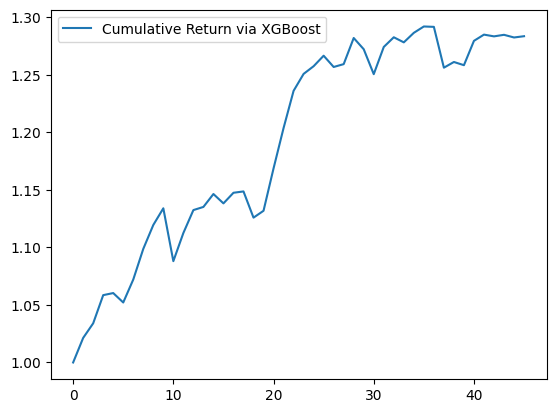

              precision    recall  f1-score   support

           0       0.56      0.67      0.61      6777
           1       0.58      0.47      0.52      6723

    accuracy                           0.57     13500
   macro avg       0.57      0.57      0.56     13500
weighted avg       0.57      0.57      0.56     13500



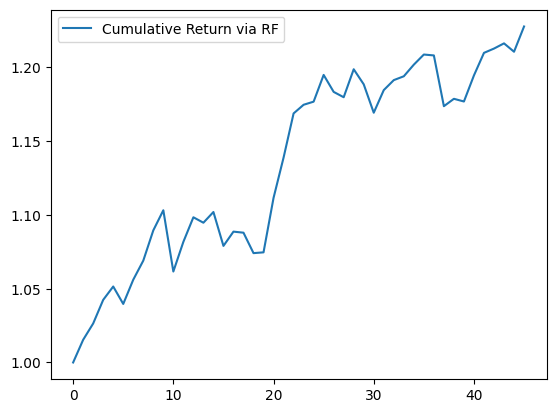

In [5]:
################################################## above code from chapter 5

# model fitting
from sklearn.ensemble import GradientBoostingClassifier,RandomForestClassifier
from xgboost import XGBClassifier
#clf = GradientBoostingClassifier(n_estimators=10, max_depth=5, min_samples_split=2, learning_rate=0.1)
#clf = RandomForestClassifier(n_estimators=10,max_depth=5,min_samples_leaf=2)
clf = XGBClassifier(learning_rate=0.1)
clf.fit(X_train,y_train)

# performance in test sample
y_pred = clf.predict(X_test)
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))
np.corrcoef([y_test,y_pred]) # Information Coefficient, IC

## portfolio
holding_matrix = np.zeros((n1-p,300))
for j in range(n1-p):
    #prob = clf.predict_proba(test[j:j+5,:].T)[:,1]
    prob = clf.predict_proba(test[j:j+p,:].T)[:,1]
    long_position = prob.argsort()[-10:]
    short_position = prob.argsort()[:10]
    holding_matrix[j,long_position] = 0.05
    holding_matrix[j,short_position] = -0.05

tmp_ret_xg = np.sum(holding_matrix*test[p:],axis = 1)
portfolio_ret_xg = np.append(0,tmp_ret_xg)
plt.plot(np.cumprod(1+portfolio_ret_xg))
plt.legend(['Cumulative Return via XGBoost'])
plt.show()
plt.savefig(r'./imgs_chapter10/stockret-xg')


# model fitting
#clf = GradientBoostingClassifier(n_estimators=10, max_depth=2, min_samples_split=2, learning_rate=0.1)
clf =  RandomForestClassifier(n_estimators=10,max_depth=5,min_samples_split=2)
#clf = XGBClassifier(learning_rate=0.1)
clf.fit(X_train,y_train)

# performance in test sample
y_pred = clf.predict(X_test)
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))
np.corrcoef([y_test,y_pred]) # Information Coefficient, IC

## portfolio
holding_matrix = np.zeros((n1-p,300))
for j in range(n1-p):
    prob = clf.predict_proba(test[j:j+p,:].T)[:,1]
    long_position = prob.argsort()[-10:]
    short_position = prob.argsort()[:10]
    holding_matrix[j,long_position] = 0.05
    holding_matrix[j,short_position] = -0.05

tmp_ret_rf = np.sum(holding_matrix*test[p:],axis = 1)
portfolio_ret_rf = np.append(0,tmp_ret_rf)
plt.plot(np.cumprod(1+portfolio_ret_rf))
plt.legend(['Cumulative Return via RF'])
plt.savefig(r'./imgs_chapter10/stockret-rf')

              precision    recall  f1-score   support

           0       0.55      0.79      0.65      6777
           1       0.63      0.36      0.46      6723

    accuracy                           0.58     13500
   macro avg       0.59      0.57      0.55     13500
weighted avg       0.59      0.58      0.55     13500



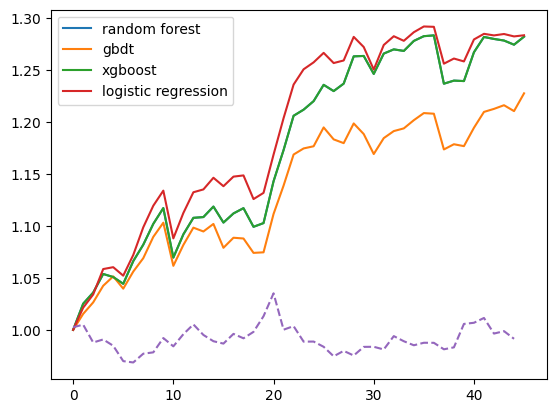

In [ ]:
# model fitting
clf = GradientBoostingClassifier(n_estimators=10, max_depth=5, min_samples_split=2, learning_rate=0.1)
#clf = RandomForestClassifier(n_estimators=10,min_samples_leaf=2)
#clf = XGBClassifier(learning_rate=0.1)
clf.fit(X_train,y_train)

# performance in test sample
y_pred = clf.predict(X_test)
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))
np.corrcoef([y_test,y_pred]) # Information Coefficient, IC

## portfolio
holding_matrix = np.zeros((n1-p,300))
for j in range(n1-p):
    #prob = clf.predict_proba(test[j:j+5,:].T)[:,1]
    prob = clf.predict_proba(test[j:j+p,:].T)[:,1]
    long_position = prob.argsort()[-10:]
    short_position = prob.argsort()[:10]
    holding_matrix[j,long_position] = 0.05
    holding_matrix[j,short_position] = -0.05

tmp_ret_gb = np.sum(holding_matrix*test[p:],axis = 1)
portfolio_ret_gb = np.append(0,tmp_ret_gb)
plt.plot(np.cumprod(1+portfolio_ret_gb))


plt.legend(['Cumulative Return via GBDT'],loc='upper left')
plt.show()
plt.savefig(r'./imgs_chapter10/stockret-gb')



plt.plot(np.cumprod(1+portfolio_ret_rf))
plt.plot(np.cumprod(1+portfolio_ret_gb))
plt.plot(np.cumprod(1+portfolio_ret_xg))
plt.plot(np.cumprod(1+portfolio_ret),'--')
plt.legend(['random forest','gbdt','xgboost','logistic regression'])
plt.savefig(r'./imgs_chapter10/stockret-trees')
